## 1. Environment Setup & Library Imports

In [ ]:
import shutil
import os

if os.path.exists("/content/drive"):
    shutil.rmtree("/content/drive")

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"
!ls -lh "/content/drive/MyDrive/maryon"
!ls -l "/content/drive/.shortcut-targets-by-id"
!ls -l "/content/drive/.shortcut-targets-by-id/1iFs5F13ES7HRR7-xmukAsBrcLo_ZVc8t"
!ls -lh "/content/drive/.shortcut-targets-by-id/1iFs5F13ES7HRR7-xmukAsBrcLo_ZVc8t/maryon"

'Basic Doc'	    Educational_Doc	 Resume
 Classroom	    maryon		 Slot_booking.drawio
'Colab Notebooks'   MJI_2026-03-22.pdf	' Tech Certificates'
ls: /content/drive/MyDrive/maryon: No such file or directory
lrw------- 1 root root 0 Jul 19 17:33 /content/drive/MyDrive/maryon -> /content/drive/.shortcut-targets-by-id/1iFs5F13ES7HRR7-xmukAsBrcLo_ZVc8t/maryon
total 0
total 4
drwx------ 1 root root 4096 Jul 19 18:53 maryon
total 30M
-rw------- 1 root root 7.2M Jul 19 18:47 best_model.pth
-rw------- 1 root root  22M Jul 19 18:47 checkpoint.pth
drwx------ 2 root root 4.0K Jul 15 03:28 dataset
-rw------- 1 root root 1.4M Jul 20 08:34 SAR2.ipynb


In [ ]:
# ==========================================================
# Cell 1.1 : Install Required Libraries
# ==========================================================

!pip install -q torch torchvision torchaudio
!pip install -q rasterio
!pip install -q tifffile
!pip install -q albumentations
!pip install -q opencv-python
!pip install -q scikit-image
!pip install -q matplotlib
!pip install -q scikit-learn
!pip install -q pandas
!pip install -q tqdm
!pip install -q gdown
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.7 MB/s eta 0:00:00


In [ ]:
# ==========================================================
# Cell 1.2 : Import Libraries
# ==========================================================

import os
import glob
import cv2
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import rasterio
from rasterio.enums import Resampling

from skimage import exposure

import albumentations as A

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from urllib.parse import urlparse

from torchmetrics.classification import MulticlassJaccardIndex
from torchmetrics.classification import MulticlassF1Score
from torchmetrics.classification import MulticlassPrecision
from torchmetrics.classification import MulticlassRecall

# Set random seed
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

True
1
Tesla T4


## 2. Dataset Download & Extraction

In [ ]:
# ==========================================================
# Cell 2.1 : Download MADOS Dataset
# ==========================================================

import gdown
from urllib.parse import urlparse
import os

gdrive_url = "https://drive.google.com/file/d/1oWI-uish8EfLeD2YdK6yL6T99glXtVaZ/view?usp=drive_link"

def get_file_id(url):
    parsed = urlparse(url)
    return parsed.path.split("/")[3]

file_id = get_file_id(gdrive_url)

zip_path = "/content/mados.zip"

if not os.path.exists(zip_path):

    print("Downloading MADOS Dataset...")

    gdown.download(
        id=file_id,
        output=zip_path,
        quiet=False
    )

else:

    print("Dataset already downloaded.")

if os.path.exists(zip_path):

    print("Download Successful!")

else:

    print("Download Failed!")

Downloading...
From (original): https://drive.google.com/uc?id=1oWI-uish8EfLeD2YdK6yL6T99glXtVaZ
From (redirected): https://drive.google.com/uc?id=1oWI-uish8EfLeD2YdK6yL6T99glXtVaZ&confirm=t&uuid=921f7d51-1a0c-4405-9166-b74723ebbbcd
To: /content/mados.zip
100%|██████████| 4.04G/4.04G [01:04<00:00, 62.9MB/s]

Download Successful!


In [ ]:
# ==========================================================
# Cell 2.2 : Extract Dataset
# ==========================================================

extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:

    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

DATASET_PATH = "/content/dataset/MADOS"

print("Dataset Path:", DATASET_PATH)

Dataset Extracted Successfully!
Dataset Path: /content/dataset/MADOS


## 3. Dataset Preparation

In [ ]:
# ==========================================================
# Cell 3.1 : Define Dataset Path
# ==========================================================

import os

DATASET_PATH = "/content/dataset/MADOS"

print("Dataset Path:", DATASET_PATH)

if os.path.exists(DATASET_PATH):
    print("✅ Dataset Found!")
else:
    print("❌ Dataset NOT Found!")
    print("\nAvailable folders inside /content/dataset:")

    if os.path.exists("/content/dataset"):
        print(os.listdir("/content/dataset"))
    else:
        print("/content/dataset does not exist.")

Dataset Path: /content/dataset/MADOS
✅ Dataset Found!


In [ ]:
# ==========================================================
# Cell 3.2 : Verify Dataset Structure
# ==========================================================

print("=" * 60)
print("VERIFYING MADOS DATASET")
print("=" * 60)

scene_count = 0

for root, dirs, files in os.walk(DATASET_PATH):

    print(f"\nDirectory : {root}")
    print(f"Subfolders : {len(dirs)}")
    print(f"Files      : {len(files)}")

    if root == DATASET_PATH:
        scene_count = len(dirs)

print("\n" + "=" * 60)
print("Total Scenes :", scene_count)
print("=" * 60)

VERIFYING MADOS DATASET

Directory : /content/dataset/MADOS
Subfolders : 175
Files      : 0

Directory : /content/dataset/MADOS/Scene_53
Subfolders : 3
Files      : 0

Directory : /content/dataset/MADOS/Scene_53/60
Subfolders : 0
Files      : 10

Directory : /content/dataset/MADOS/Scene_53/10
Subfolders : 0
Files      : 100

Directory : /content/dataset/MADOS/Scene_53/20
Subfolders : 0
Files      : 90

Directory : /content/dataset/MADOS/Scene_42
Subfolders : 3
Files      : 0

Directory : /content/dataset/MADOS/Scene_42/60
Subfolders : 0
Files      : 13

Directory : /content/dataset/MADOS/Scene_42/10
Subfolders : 0
Files      : 130

Directory : /content/dataset/MADOS/Scene_42/20
Subfolders : 0
Files      : 117

Directory : /content/dataset/MADOS/Scene_158
Subfolders : 3
Files      : 0

Directory : /content/dataset/MADOS/Scene_158/60
Subfolders : 0
Files      : 4

Directory : /content/dataset/MADOS/Scene_158/10
Subfolders : 0
Files      : 40

Directory : /content/dataset/MADOS/Scene_158/

In [ ]:
import os

scene = sorted(os.listdir(DATASET_PATH))[0]

scene_path = os.path.join(DATASET_PATH, scene)

print("Scene Name:", scene)

for root, dirs, files in os.walk(scene_path):

    print("\n", root)

    for f in sorted(files):
        print("   ", f)

Scene Name: Scene_0

 /content/dataset/MADOS/Scene_0

 /content/dataset/MADOS/Scene_0/60
    Scene_0_L2R_rhorc_442_1.tif
    Scene_0_L2R_rhorc_442_2.tif
    Scene_0_L2R_rhorc_442_3.tif
    Scene_0_L2R_rhorc_442_4.tif
    Scene_0_L2R_rhorc_442_5.tif
    Scene_0_L2R_rhorc_442_6.tif
    Scene_0_L2R_rhorc_442_7.tif
    Scene_0_L2R_rhorc_442_8.tif
    Scene_0_L2R_rhorc_442_9.tif

 /content/dataset/MADOS/Scene_0/10
    Scene_0_L2R_cl_1.tif
    Scene_0_L2R_cl_2.tif
    Scene_0_L2R_cl_3.tif
    Scene_0_L2R_cl_4.tif
    Scene_0_L2R_cl_5.tif
    Scene_0_L2R_cl_6.tif
    Scene_0_L2R_cl_7.tif
    Scene_0_L2R_cl_8.tif
    Scene_0_L2R_cl_9.tif
    Scene_0_L2R_conf_1.tif
    Scene_0_L2R_conf_2.tif
    Scene_0_L2R_conf_3.tif
    Scene_0_L2R_conf_4.tif
    Scene_0_L2R_conf_5.tif
    Scene_0_L2R_conf_6.tif
    Scene_0_L2R_conf_7.tif
    Scene_0_L2R_conf_8.tif
    Scene_0_L2R_conf_9.tif
    Scene_0_L2R_rep_1.tif
    Scene_0_L2R_rep_2.tif
    Scene_0_L2R_rep_3.tif
    Scene_0_L2R_rep_4.tif
    Scene_0_L2R

In [ ]:
# ==========================================================
# Cell 4.1 : Build Multispectral Image-Mask Pairs
# ==========================================================

spectral_images = []
mask_images = []

for scene in sorted(os.listdir(DATASET_PATH)):

    scene_path = os.path.join(DATASET_PATH, scene)

    folder10 = os.path.join(scene_path, "10")
    folder20 = os.path.join(scene_path, "20")

    if not os.path.isdir(folder10) or not os.path.isdir(folder20):
        continue

    for i in range(1,10):

        band_paths = [
            os.path.join(folder10, f"{scene}_L2R_rhorc_492_{i}.tif"),
            os.path.join(folder10, f"{scene}_L2R_rhorc_559_{i}.tif"),
            os.path.join(folder10, f"{scene}_L2R_rhorc_665_{i}.tif"),
            os.path.join(folder10, f"{scene}_L2R_rhorc_833_{i}.tif"),
            os.path.join(folder20, f"{scene}_L2R_rhorc_1610_{i}.tif"),
            os.path.join(folder20, f"{scene}_L2R_rhorc_2186_{i}.tif"),
        ]

        mask = os.path.join(folder10, f"{scene}_L2R_cl_{i}.tif")

        if all(os.path.exists(path) for path in band_paths) and os.path.exists(mask):

            spectral_images.append(tuple(band_paths))
            mask_images.append(mask)

print("Total Images :", len(spectral_images))
print("Total Masks  :", len(mask_images))

Total Images : 1284
Total Masks  : 1284


In [ ]:
train_images, val_images, train_masks, val_masks = train_test_split(
    spectral_images,
    mask_images,
    test_size=0.2,
    random_state=42
)

print("Training :", len(train_images))
print("Validation :", len(val_images))

Training : 1027
Validation : 257


In [ ]:
# ==========================================================
# Cell 4.3 : MADOS Dataset Class (with Data Augmentation)
# ==========================================================

class MADOSDataset(Dataset):

    def __init__(self, image_groups, mask_paths, transform=None):

        self.image_groups = image_groups
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):

        return len(self.image_groups)

    def __getitem__(self, idx):

        # -----------------------------
        # Read Multispectral Bands
        # -----------------------------
        band_arrays = []

        for band_path in self.image_groups[idx]:
            with rasterio.open(band_path) as src:
                band = src.read(1)

            band = cv2.resize(band, (256, 256), interpolation=cv2.INTER_LINEAR)
            band_arrays.append(band.astype(np.float32))

        image = np.stack(band_arrays, axis=-1)
        image = image.astype(np.float32) / 255.0

        # -----------------------------
        # Read Mask
        # -----------------------------
        with rasterio.open(self.mask_paths[idx]) as src:

            mask = src.read(1)

        mask = cv2.resize(
            mask,
            (256, 256),
            interpolation=cv2.INTER_NEAREST
        )

        # -----------------------------
        # Convert Labels
        # -----------------------------
        unique_labels = np.unique(mask)

        label_map = {}

        for new_id, old_id in enumerate(unique_labels):

            label_map[old_id] = new_id

        new_mask = np.zeros_like(mask)

        for old_id, new_id in label_map.items():

            new_mask[mask == old_id] = new_id

        # -----------------------------
        # Apply Data Augmentation
        # -----------------------------
        if self.transform is not None:

            augmented = self.transform(
                image=image,
                mask=new_mask
            )

            image = augmented["image"]
            new_mask = augmented["mask"]

        # -----------------------------
        # Convert to Tensor
        # -----------------------------
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(new_mask).long()

        return image, mask

In [ ]:
# ==========================================================
# Cell 4.4 : Data Augmentation
# ==========================================================

train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),

])

In [ ]:
# ==========================================================
# Create Dataset
# ==========================================================
train_dataset = MADOSDataset(
    train_images,
    train_masks,
    transform=train_transform
)

val_dataset = MADOSDataset(
    val_images,
    val_masks,
    transform=None
)

print("Training Samples :", len(train_dataset))
print("Validation Samples :", len(val_dataset))

Training Samples : 1027
Validation Samples : 257


In [ ]:
# ==========================================================
# Create DataLoader
# ==========================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("DataLoader Created Successfully")

DataLoader Created Successfully


In [ ]:
# ==========================================================
# Verify DataLoader
# ==========================================================

images, masks = next(iter(train_loader))

print("Image Shape :", images.shape)
print("Mask Shape :", masks.shape)

print("Unique Labels :", torch.unique(masks))

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Image Shape : torch.Size([8, 3, 256, 256])
Mask Shape : torch.Size([8, 256, 256])
Unique Labels : tensor([0, 1, 2])


In [ ]:
# ==========================================================
# Cell 5.1 : Find Number of Classes
# ==========================================================

all_labels = set()

for _, masks in train_loader:

    all_labels.update(torch.unique(masks).tolist())

num_classes = len(all_labels)

print("Classes :", sorted(all_labels))
print("Number of Classes :", num_classes)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Classes : [0, 1, 2, 3, 4]
Number of Classes : 5


In [ ]:
# ==========================================================
# Cell 5.2 : Simple U-Net
# ==========================================================

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)

        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):

    def __init__(self, n_classes):

        super().__init__()

        self.down1 = DoubleConv(6,64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64,128)
        self.pool2 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128,256)

        self.up1 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.conv1 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.conv2 = DoubleConv(128,64)

        self.out = nn.Conv2d(64,n_classes,1)

    def forward(self,x):

        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        b = self.bridge(p2)

        u1 = self.up1(b)
        u1 = torch.cat([u1,c2],dim=1)
        c3 = self.conv1(u1)

        u2 = self.up2(c3)
        u2 = torch.cat([u2,c1],dim=1)
        c4 = self.conv2(u2)

        return self.out(c4)

In [ ]:
# ==========================================================
# Create Model
# ==========================================================
import torch.nn as nn
model = UNet(n_classes=num_classes).to(device)

class_weights = torch.tensor(
    [0.05, 1.0, 1.0, 1.0, 1.0],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Weighted CrossEntropy Loss Initialized")

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

print(model)

Weighted CrossEntropy Loss Initialized
UNet(
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bridge): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   

In [ ]:
# ==========================================================
# Test Model
# ==========================================================

images, masks = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Input : torch.Size([8, 3, 256, 256])
Output: torch.Size([8, 5, 256, 256])


In [ ]:
num_classes = 5

iou_metric = MulticlassJaccardIndex(
    num_classes=num_classes
).to(device)

f1_metric = MulticlassF1Score(
    num_classes=num_classes,
    average="macro"
).to(device)

precision_metric = MulticlassPrecision(
    num_classes=num_classes,
    average="macro"
).to(device)

recall_metric = MulticlassRecall(
    num_classes=num_classes,
    average="macro"
).to(device)

class_weights = torch.tensor([0.05,1,1,1,1],dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

save_dir = "/content/drive/.shortcut-targets-by-id/1iFs5F13ES7HRR7-xmukAsBrcLo_ZVc8t/maryon"

checkpoint_path = os.path.join(save_dir,"checkpoint.pth")

best_model_path = os.path.join(save_dir,"best_model.pth")

In [ ]:
#Delete the checkpoint and best model:
import os

if os.path.exists(checkpoint_path):
    os.remove(checkpoint_path)

if os.path.exists(best_model_path):
    os.remove(best_model_path)

print("Old checkpoint deleted.")

Old checkpoint deleted.


In [ ]:
# ==========================================================
# Cell 6.1 : Training with Automatic Checkpoints
# ==========================================================

import os
import torch

# ----------------------------------------------------------
# CHANGE ONLY THIS PATH IF NEEDED
# ----------------------------------------------------------

save_dir = "/content/drive/.shortcut-targets-by-id/1iFs5F13ES7HRR7-xmukAsBrcLo_ZVc8t/maryon"

os.makedirs(save_dir, exist_ok=True)

checkpoint_path = os.path.join(save_dir, "checkpoint.pth")
best_model_path = os.path.join(save_dir, "best_model.pth")

# ----------------------------------------------------------
# Resume Training
# ----------------------------------------------------------

start_epoch = 0
best_accuracy = 0.0

train_loss_history = []
train_accuracy_history = []

if os.path.exists(checkpoint_path):

    print("="*60)
    print("Loading Previous Checkpoint...")

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    start_epoch = checkpoint["epoch"] + 1
    best_accuracy = checkpoint["best_accuracy"]

    train_loss_history = checkpoint.get("train_loss_history", [])
    train_accuracy_history = checkpoint.get("train_accuracy_history", [])

    print(f"Resuming from Epoch {start_epoch}")

else:
    train_loss_history = []
    train_accuracy_history = []

In [ ]:
# ==========================================================
# Cell 6.2 : Final Training Loop
# ==========================================================

from tqdm import tqdm

# --------------------------------------
# Metrics History
# --------------------------------------

if "train_loss_history" not in globals():
    train_loss_history = []

if "train_accuracy_history" not in globals():
    train_accuracy_history = []

if "iou_history" not in globals():
    iou_history = []

if "precision_history" not in globals():
    precision_history = []

if "recall_history" not in globals():
    recall_history = []

if "f1_history" not in globals():
    f1_history = []

# --------------------------------------
# Training
# --------------------------------------

num_epochs = 50

best_iou = 0.0

for epoch in range(start_epoch, num_epochs):

    print("="*70)
    print(f"Epoch {epoch+1}/{num_epochs}")

    model.train()

    running_loss = 0

    correct = 0
    total = 0

    # Reset Metrics
    iou_metric.reset()
    precision_metric.reset()
    recall_metric.reset()
    f1_metric.reset()

    progress = tqdm(train_loader)

    for images, masks in progress:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == masks).sum().item()

        total += masks.numel()

        # Update Metrics
        iou_metric.update(preds, masks)
        precision_metric.update(preds, masks)
        recall_metric.update(preds, masks)
        f1_metric.update(preds, masks)

        progress.set_postfix(loss=loss.item())

    # --------------------------------------
    # Calculate Metrics
    # --------------------------------------

    train_loss = running_loss / len(train_loader)

    accuracy = 100 * correct / total

    iou = iou_metric.compute().item()

    precision = precision_metric.compute().item()

    recall = recall_metric.compute().item()

    f1 = f1_metric.compute().item()

    train_loss_history.append(train_loss)

    train_accuracy_history.append(accuracy)

    iou_history.append(iou)

    precision_history.append(precision)

    recall_history.append(recall)

    f1_history.append(f1)

    print(f"Training Loss : {train_loss:.4f}")
    print(f"Accuracy      : {accuracy:.2f}%")
    print(f"IoU           : {iou:.4f}")
    print(f"Precision     : {precision:.4f}")
    print(f"Recall        : {recall:.4f}")
    print(f"F1 Score      : {f1:.4f}")

    # --------------------------------------
    # Save Best Model
    # --------------------------------------

    if iou > best_iou:

        best_iou = iou

        torch.save(model.state_dict(), best_model_path)

        print("✅ Best Model Saved")

    # --------------------------------------
    # Save Checkpoint
    # --------------------------------------

    checkpoint = {

        "epoch": epoch,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),

        "best_iou": best_iou,

        "train_loss_history": train_loss_history,

        "train_accuracy_history": train_accuracy_history,

        "iou_history": iou_history,

        "precision_history": precision_history,

        "recall_history": recall_history,

        "f1_history": f1_history

    }

    torch.save(checkpoint, checkpoint_path)

    print("✅ Checkpoint Saved")

    print(f"Best IoU : {best_iou:.4f}")

print("\n🎉 Training Completed Successfully!")

Epoch 1/50


  0%|          | 0/129 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
100%|██████████| 129/129 [00:35<00:00,  3.65it/s, loss=0.0994]


Training Loss : 0.7406
Accuracy      : 85.16%
IoU           : 0.1718
Precision     : 0.1997
Recall        : 0.1974
F1 Score      : 0.1871
✅ Best Model Saved
✅ Checkpoint Saved
Best IoU : 0.1718
Epoch 2/50


  0%|          | 0/129 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
100%|██████████| 129/129 [00:35<00:00,  3.63it/s, loss=1.45]


Training Loss : 0.4455
Accuracy      : 99.05%
IoU           : 0.1981
Precision     : 0.1981
Recall        : 0.2000
F1 Score      : 0.1990
✅ Best Model Saved
✅ Checkpoint Saved
Best IoU : 0.1981
Epoch 3/50


...

Training Loss : 0.3731
Accuracy      : 98.19%
IoU           : 0.2168
Precision     : 0.2303
Recall        : 0.2422
F1 Score      : 0.2353
✅ Checkpoint Saved
Best IoU : 0.2193
Epoch 49/50


  0%|          | 0/129 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
100%|██████████| 129/129 [00:38<00:00,  3.35it/s, loss=0.112]


Training Loss : 0.3762
Accuracy      : 98.05%
IoU           : 0.2132
Precision     : 0.2247
Recall        : 0.2368
F1 Score      : 0.2295
✅ Checkpoint Saved
Best IoU : 0.2193
Epoch 50/50


  0%|          | 0/129 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
100%|██████████| 129/129 [00:38<00:00,  3.34it/s, loss=0.347]


Training Loss : 0.3690
Accuracy      : 98.28%
IoU           : 0.2192
Precision     : 0.2343
Recall        : 0.2452
F1 Score      : 0.2389
✅ Checkpoint Saved
Best IoU : 0.2193

🎉 Training Completed Successfully!


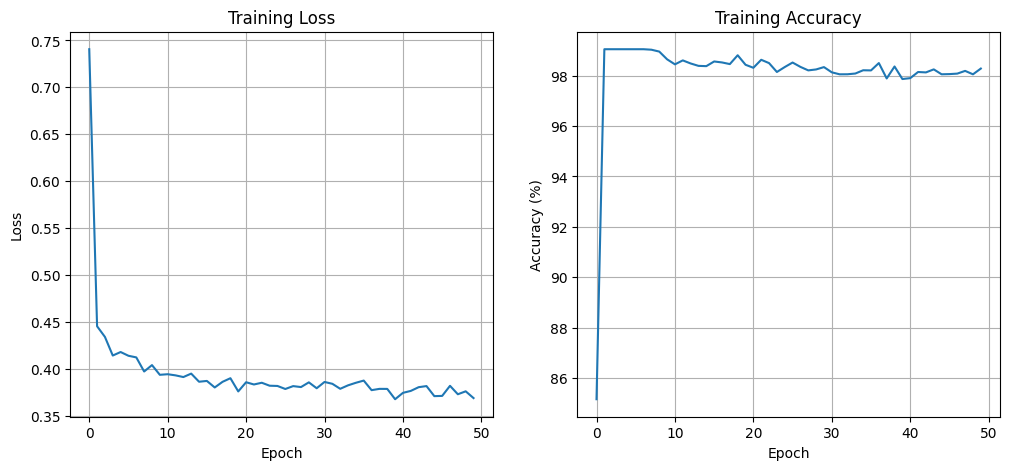

In [ ]:
# ==========================================================
# Training Curves
# ==========================================================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

plt.plot(train_loss_history)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.subplot(1,2,2)

plt.plot(train_accuracy_history)

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

In [ ]:
from collections import Counter
import numpy as np

counter = Counter()

for _, masks in train_loader:
    labels, counts = np.unique(masks.numpy(), return_counts=True)
    counter.update(dict(zip(labels, counts)))

print(counter)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Counter({np.int64(0): np.int64(66664953), np.int64(1): np.int64(610527), np.int64(2): np.int64(25955), np.int64(3): np.int64(3392), np.int64(4): np.int64(645)})


In [ ]:
# ==========================================================
# Load Best Model
# ==========================================================

best_model_path = "/content/drive/.shortcut-targets-by-id/1iFs5F13ES7HRR7-xmukAsBrcLo_ZVc8t/maryon/best_model.pth"

model.load_state_dict(torch.load(best_model_path, map_location=device))

model.eval()

print("✅ Best model loaded successfully!")

✅ Best model loaded successfully!


In [ ]:
# ==========================================================
# Select One Validation Image
# ==========================================================

index = 1   # Change this to test different images

image, mask = val_dataset[index]

print(image.shape)
print(mask.shape)

torch.Size([3, 256, 256])
torch.Size([256, 256])


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


In [ ]:
# ==========================================================
# Prediction
# ==========================================================

with torch.no_grad():

    input_image = image.unsqueeze(0).to(device)

    output = model(input_image)

    prediction = torch.argmax(output, dim=1)

prediction = prediction.squeeze().cpu().numpy()

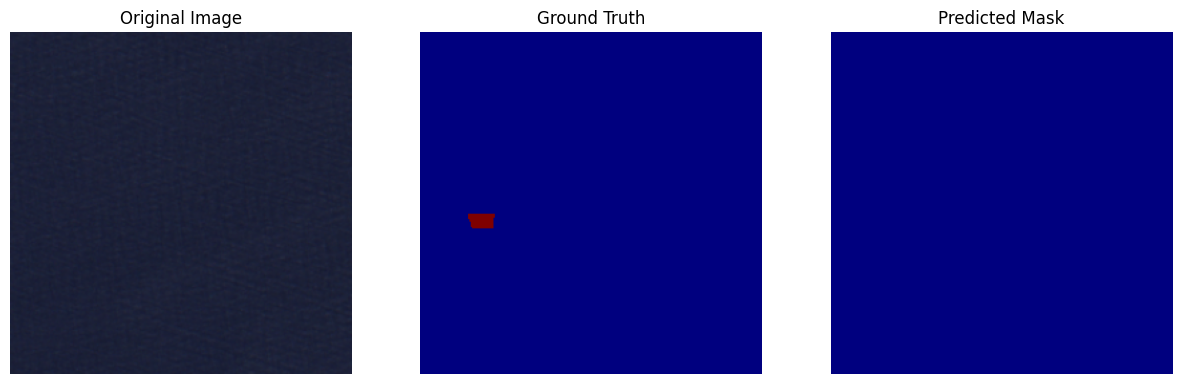

In [ ]:
# ==========================================================
# Visualization
# ==========================================================

plt.figure(figsize=(15,5))

# Original Image
plt.subplot(1,3,1)
plt.imshow(image.permute(1,2,0))
plt.title("Original Image")
plt.axis("off")

# Ground Truth
plt.subplot(1,3,2)
plt.imshow(mask, cmap="jet")
plt.title("Ground Truth")
plt.axis("off")

# Prediction
plt.subplot(1,3,3)
plt.imshow(prediction, cmap="jet")
plt.title("Predicted Mask")
plt.axis("off")

plt.show()

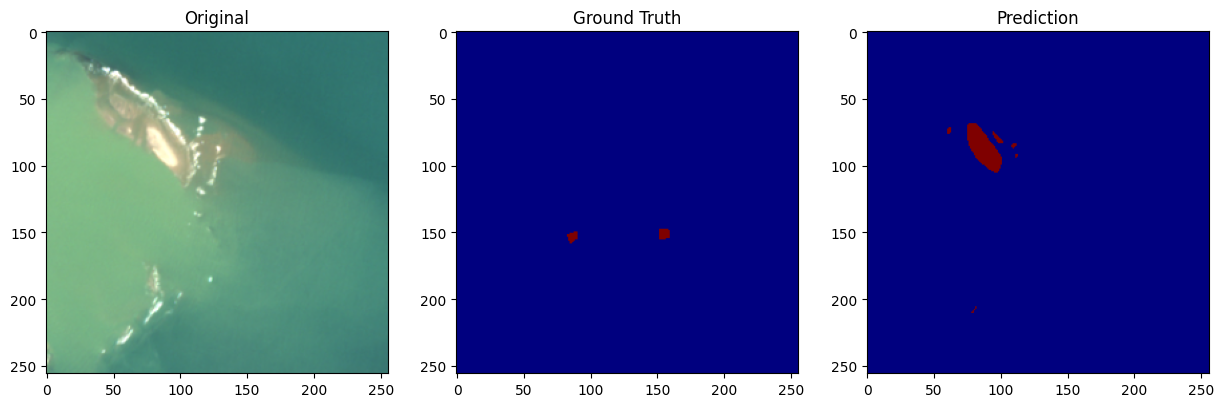

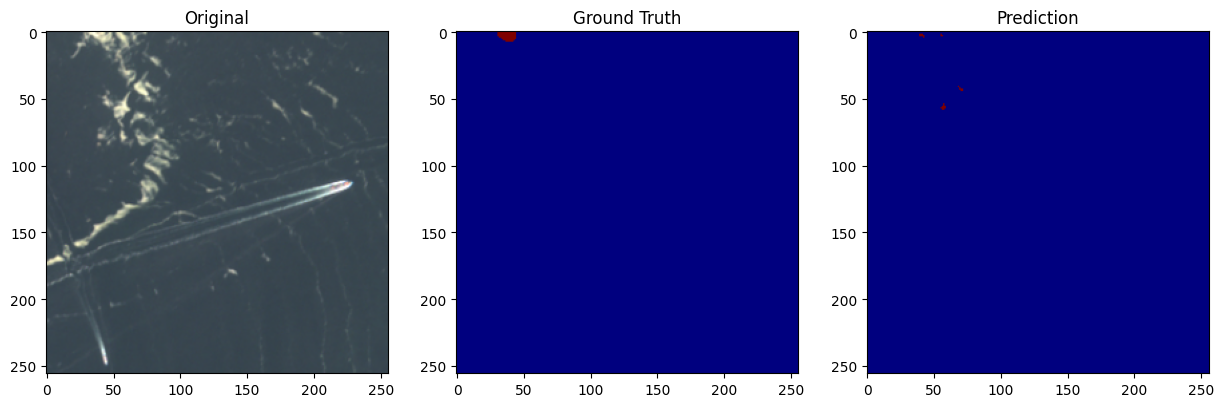

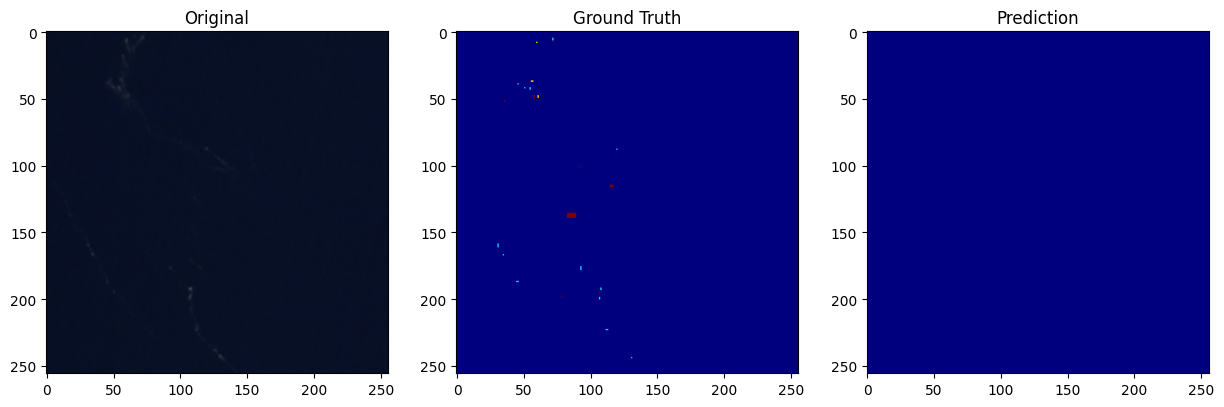

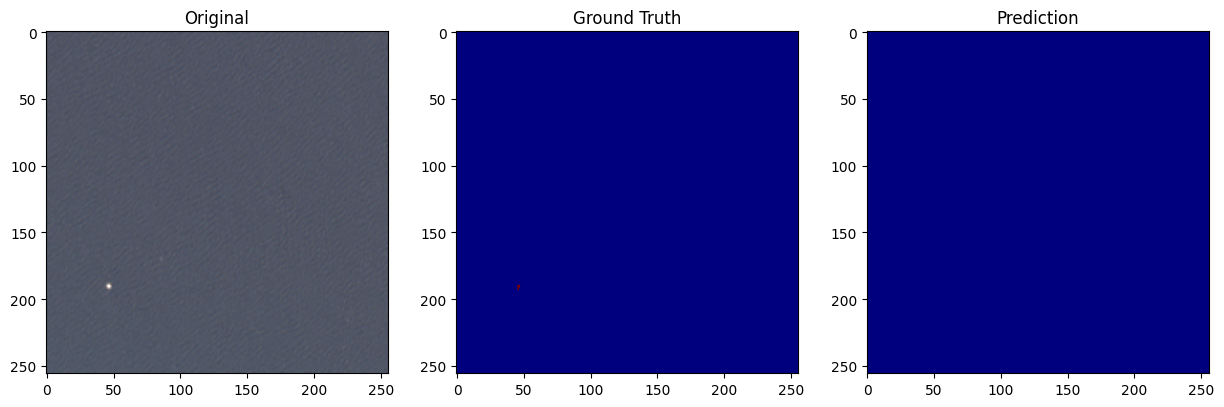

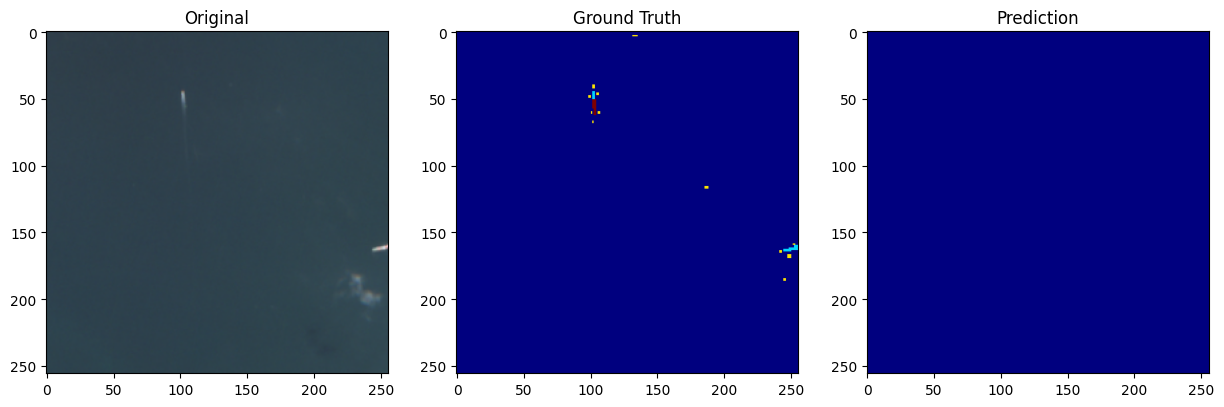

In [ ]:
# ==========================================================
# Test 5 Random Images
# ==========================================================

import random

model.eval()

for i in random.sample(range(len(val_dataset)), 5):

    image, mask = val_dataset[i]

    with torch.no_grad():

        output = model(image.unsqueeze(0).to(device))

        pred = torch.argmax(output, dim=1).squeeze().cpu().numpy()

    plt.figure(figsize=(15,5))

    plt.subplot(1,3,1)
    plt.imshow(image.permute(1,2,0))
    plt.title("Original")

    plt.subplot(1,3,2)
    plt.imshow(mask, cmap="jet")
    plt.title("Ground Truth")

    plt.subplot(1,3,3)
    plt.imshow(pred, cmap="jet")
    plt.title("Prediction")

    plt.show()

In [ ]:
#Calculate Validation Accuracy
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, masks in val_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        correct += (preds == masks).sum().item()

        total += masks.numel()

accuracy = 100 * correct / total

print(f"Validation Pixel Accuracy: {accuracy:.2f}%")

Validation Pixel Accuracy: 98.05%
